<a href="https://colab.research.google.com/github/vyasathul17/Machine-Learning/blob/main/Decision_Tree_professional_census_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing all the required libraries

Data loading

EDA - Data Preprocessing

Visualization

Label encoding or one-hot encoding

Data splitting - x, y -> train, test

Model creation



#Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving census-income_final.csv to census-income_final.csv


#Loading data

In [3]:
data = pd.read_csv("census-income_final.csv")

In [4]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#Data Cleaning

In [5]:
data.columns = data.columns.str.strip().str.replace(" ","_")

In [6]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', ''],
      dtype='object')

In [7]:
data["workclass"].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [8]:
print(data["workclass"].unique())

[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked']


In [9]:
data= data.replace(' ?',np.nan)

In [10]:
data.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14                  32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#Handling missing value

In [12]:
for col in data.columns:
  if data[col].dtype == "object":
    data[col] = data[col].fillna(data[col].mode()[0])
  else:
    data[col] = data[col].fillna(data[col].median())

In [13]:
data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [14]:
data.duplicated().sum()

np.int64(24)

In [15]:
data[data.duplicated()]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,
4881,25,Private,308144,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,Mexico,<=50K
5104,90,Private,52386,Some-college,10,Never-married,Other-service,Not-in-family,Asian-Pac-Islander,Male,0,0,35,United-States,<=50K
9171,21,Private,250051,Some-college,10,Never-married,Prof-specialty,Own-child,White,Female,0,0,10,United-States,<=50K
11631,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
13084,25,Private,195994,1st-4th,2,Never-married,Priv-house-serv,Not-in-family,White,Female,0,0,40,Guatemala,<=50K
15059,21,Private,243368,Preschool,1,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
17040,46,Private,173243,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
18555,30,Private,144593,HS-grad,9,Never-married,Other-service,Not-in-family,Black,Male,0,0,40,United-States,<=50K
18698,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
21318,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [16]:
data.drop_duplicates(inplace = True)

In [17]:
data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


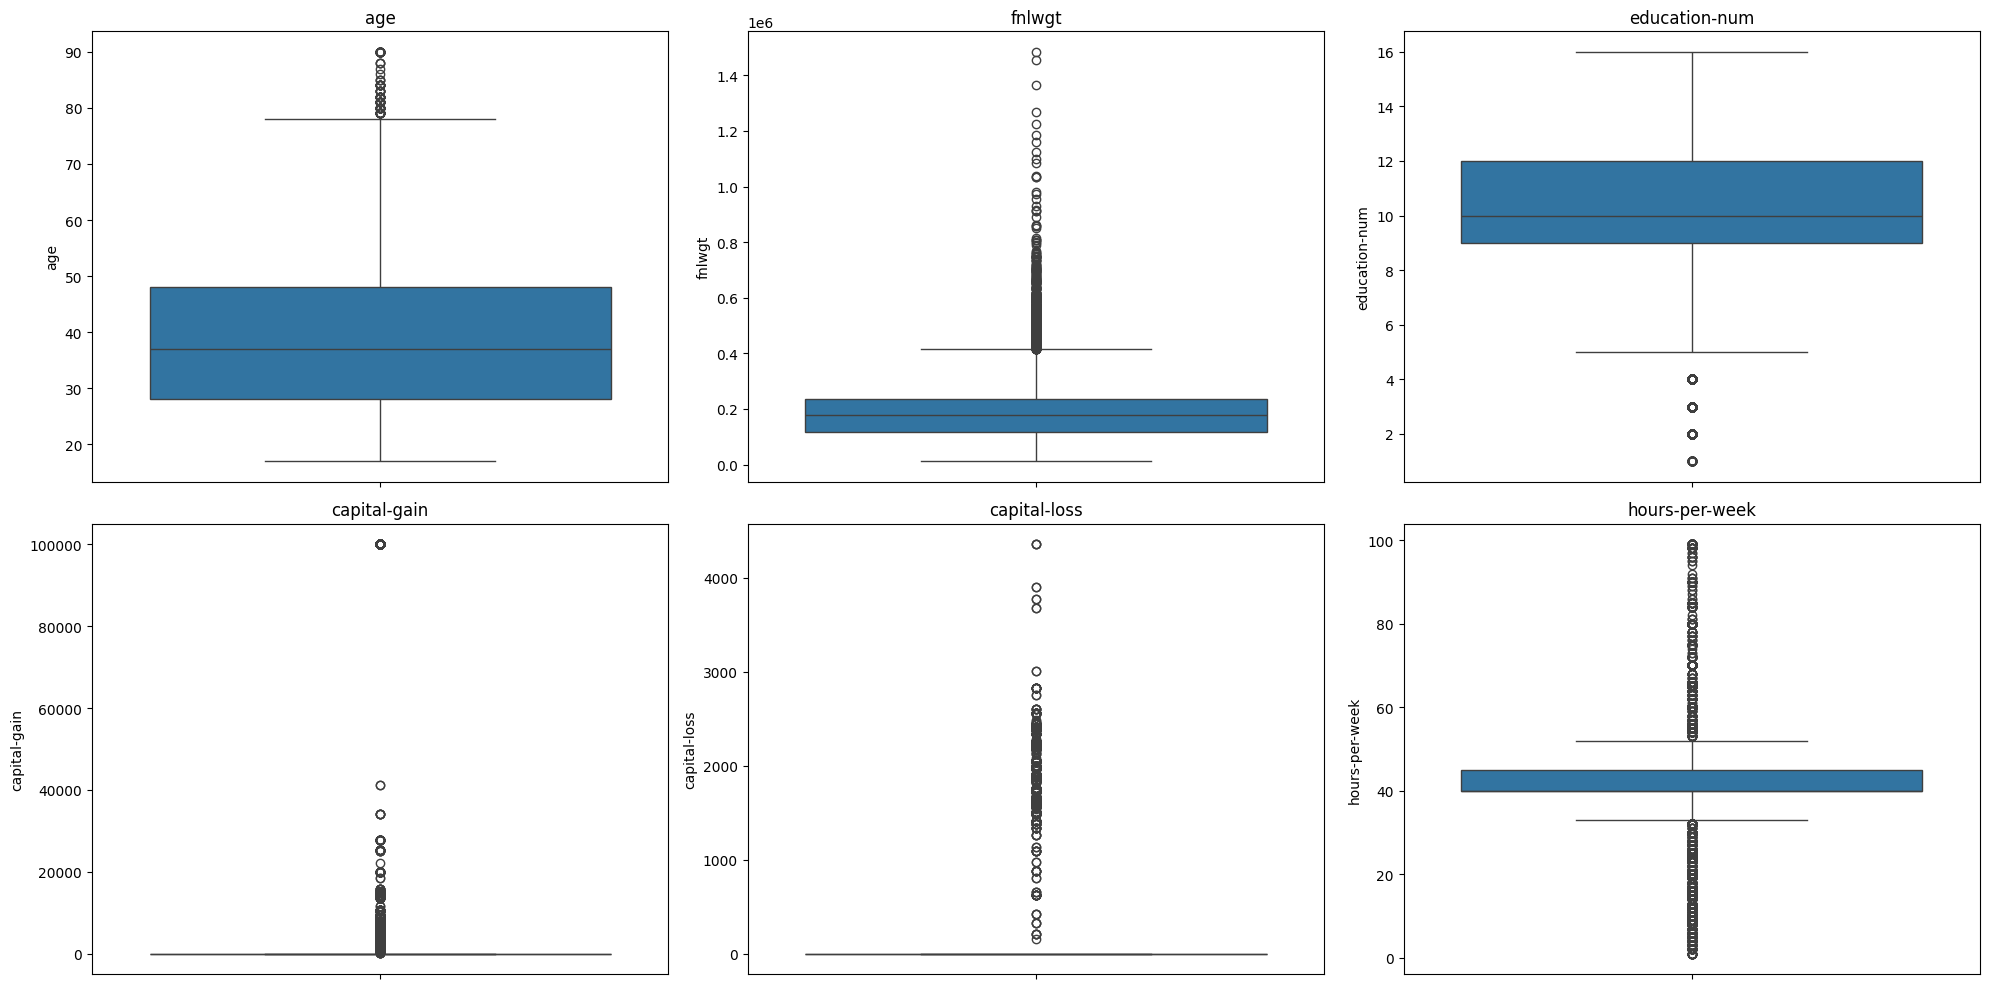

In [18]:
plt.figure(figsize = (20,10))
i = 1

for col in data.columns:
  if data[col].dtype != "object":
    plt.subplot(2,3,i)
    sns.boxplot(data=data, y= col)
    plt.title(col)
    i += 1
plt.tight_layout()
plt.show()

In [19]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', ''],
      dtype='object')

In [20]:
data.rename(columns = {"": "Income"},inplace = True)


In [21]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'Income'],
      dtype='object')

In [22]:
data.rename(columns = {"education-num":"education_num",
                       "marital-status":"marital_status",
                       "capital-gain":"capital_gain",
                       "hours-per-week":"hours_per_week"},inplace = True)

In [23]:
data.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital-loss', 'hours_per_week', 'native-country',
       'Income'],
      dtype='object')

# Feature Engineering
🔹 Convert categorical → numeric

In [24]:
x = data.drop(["Income"],axis = 1)


In [25]:
data["Income"].unique()

array([' <=50K', ' >50K'], dtype=object)

In [26]:
y = data["Income"]

In [27]:
y_final = y.map({' <=50K':0,' >50K':1})

In [28]:
y_final

,Income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,1
32558,0
32559,0


In [29]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y_final,train_size = 0.7,random_state = 42)

cat_cols = x_train.select_dtypes(include = "object").columns
num_cols = x_train.select_dtypes(exclude = "object").columns

cat_pipeline = Pipeline(steps = [(
    "encoder",OneHotEncoder(handle_unknown = "ignore",drop = "first")
)])

num_pipeline = Pipeline(steps = [
    ("scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [("num",num_pipeline,num_cols),
                   ("cat",cat_pipeline,cat_cols)]
)

pipeline = Pipeline(steps = [
    ("preprocessing",preprocessor),
    ("classifier",DecisionTreeClassifier(random_state = 42))
])

In [31]:
pipeline.fit(x_train,y_train)
pred = pipeline.predict(x_test)

In [32]:
print("Accuracy score:",accuracy_score(y_test,pred))
print("\nclassification Report:\n",classification_report(y_test,pred))
print("\nconfusion_matrix:\n",confusion_matrix(y_test,pred))

Accuracy score: 0.8070067609096496

classification Report:
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      7405
           1       0.60      0.61      0.61      2357

    accuracy                           0.81      9762
   macro avg       0.74      0.74      0.74      9762
weighted avg       0.81      0.81      0.81      9762


confusion_matrix:
 [[6430  975]
 [ 909 1448]]


In [36]:
rf_model = pipeline.named_steps["classifier"]
ohe = pipeline.named_steps["preprocessing"].named_transformers_["cat"]
encoded_ohe = ohe.get_feature_names_out(cat_cols)
std = pipeline.named_steps["preprocessing"].named_transformers_["num"]
scaler_std = std.get_feature_names_out(num_cols)

all_feature = list(encoded_ohe) + list(scaler_std)
importance = rf_model.feature_importances_
feature_important = pd.Series(importance,index = all_feature).sort_values(ascending = False)
print(feature_important.head())


occupation_ Craft-repair    0.200092
workclass_ Never-worked     0.192760
workclass_ Local-gov        0.112757
workclass_ Private          0.106475
workclass_ Self-emp-inc     0.101304
dtype: float64


#Hyperparameter Turning with pipeline

In [37]:
param_grid = {"classifier__max_depth":[3,5,10,None],
              "classifier__min_samples_split":[2,5,10]}

grid = GridSearchCV(estimator = pipeline,
                    param_grid = param_grid,cv = 5)

grid.fit(x_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital-loss',
       'hours_per_week'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object'))])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [3, 5, 10, None],
                         'classifier__min_samples_split': [2, 5, 10]})

In [38]:
print(grid.best_params_)

{'classifier__max_depth': 5, 'classifier__min_samples_split': 2}


In [39]:
best_model = grid.best_estimator_
pred_tuned = best_model.predict(x_test)

In [40]:
print("Optimized Accuracy Score:",accuracy_score(y_test,pred_tuned))
print("\nclassification Report:\n",classification_report(y_test,pred_tuned))
print("\nconfusin matrix:\n",confusion_matrix(y_test,pred_tuned))

Optimized Accuracy Score: 0.8540258143822987

classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      7405
           1       0.78      0.55      0.64      2357

    accuracy                           0.85      9762
   macro avg       0.83      0.75      0.78      9762
weighted avg       0.85      0.85      0.84      9762


confusin matrix:
 [[7045  360]
 [1065 1292]]


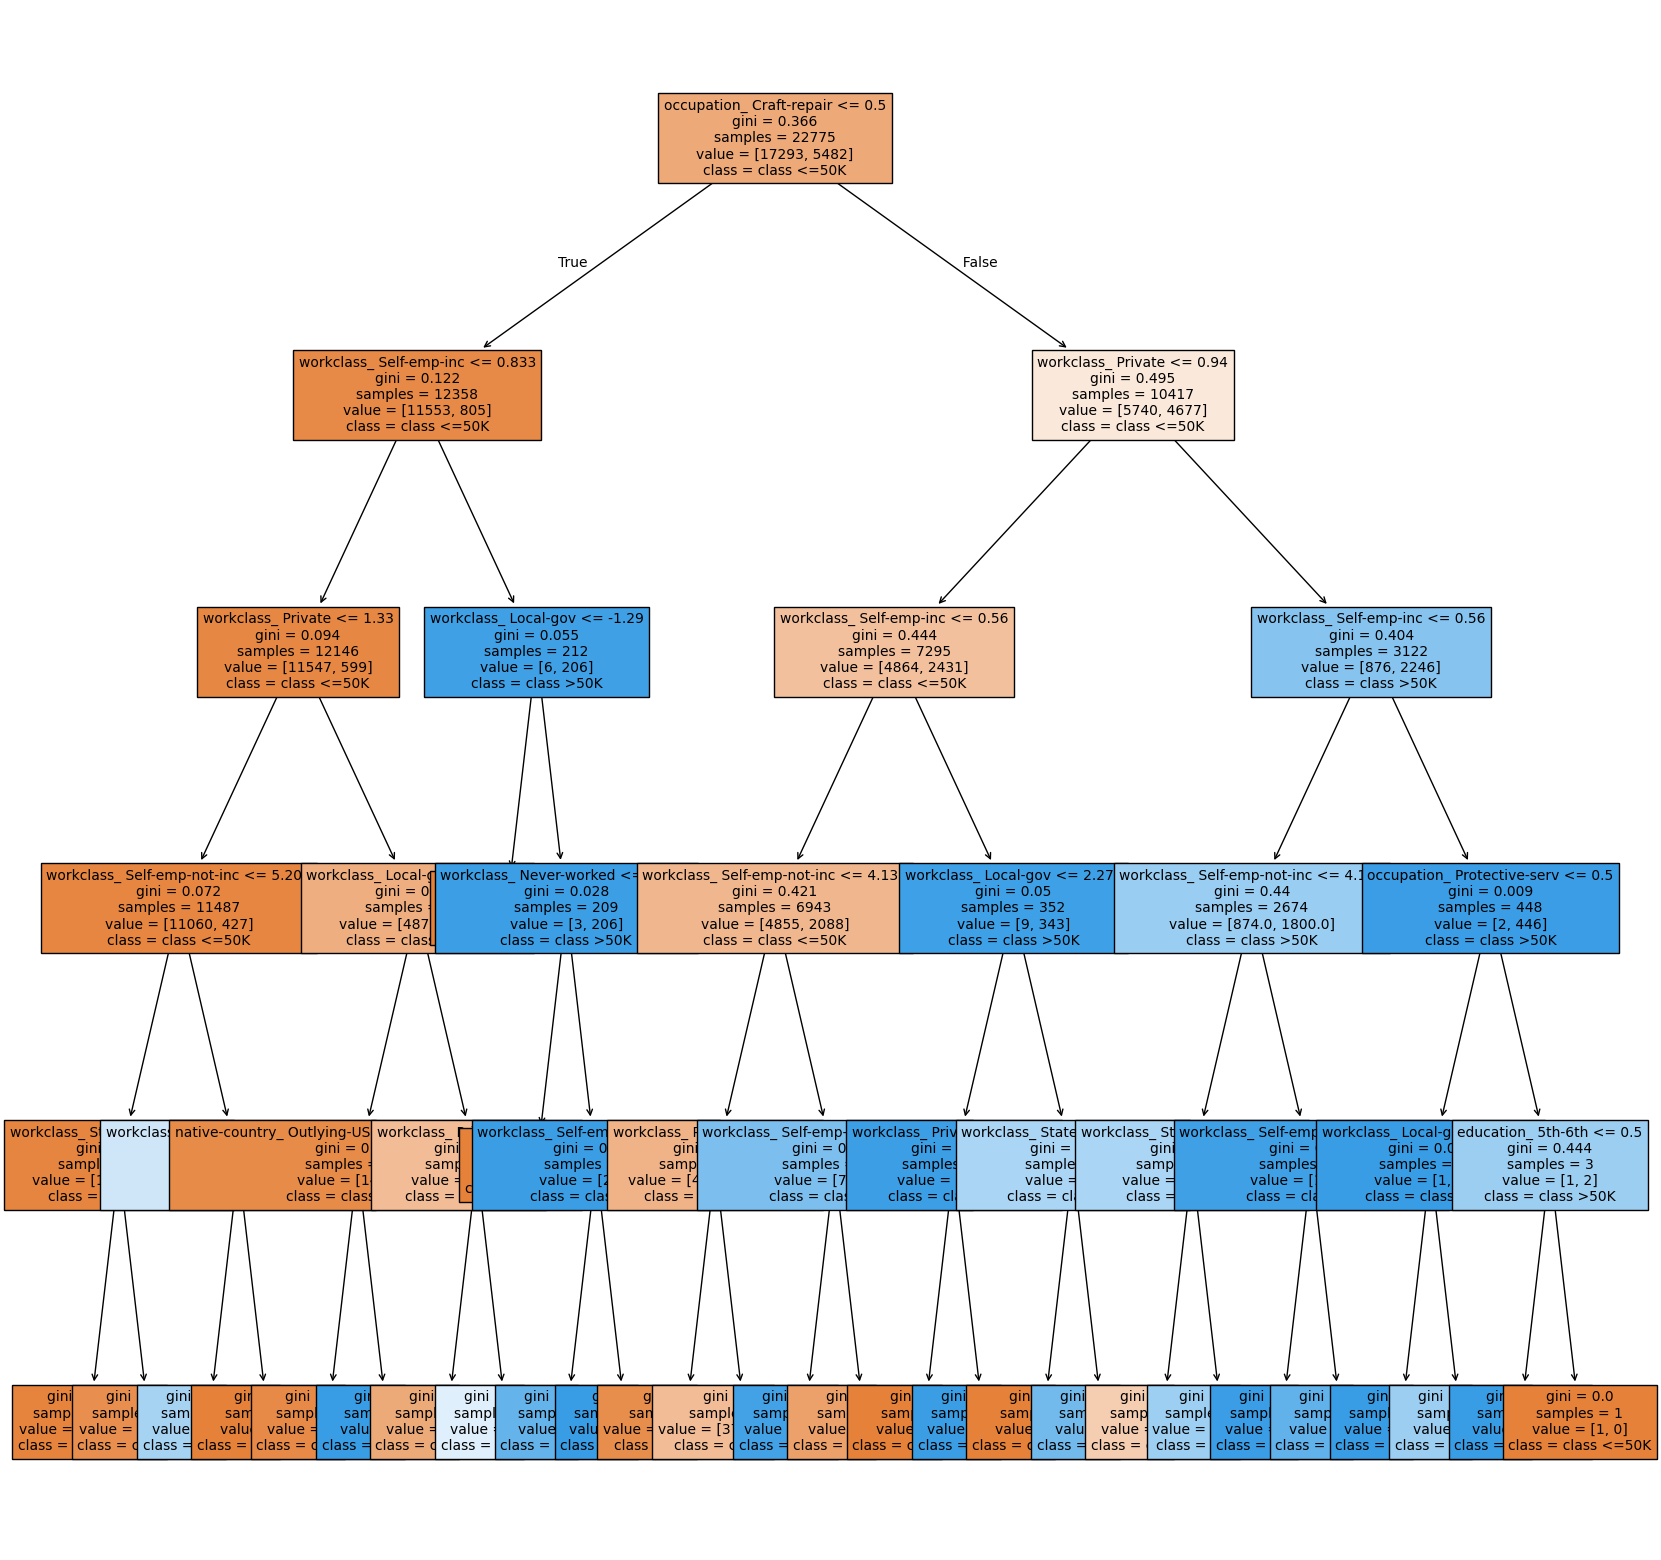

In [42]:
from sklearn import tree
class_name_list = [f"class{i}" for i in np.unique(y)]
plt.figure(figsize = (20,20))
tree.plot_tree(best_model.named_steps["classifier"],
               feature_names = all_feature,
               class_names = class_name_list,
               filled = True,
               fontsize = 10)
plt.show()